In [1]:
import pandas as pd
from matplotlib import pyplot as plt
from traitlets import observe

from utils import plot_hist_per_year, get_season, calculate_seasonal_factors, calculate_weekday_season_factors, get_season_year

# Description

In this notebook, we will perform the descriptive analysis outlined in Team Assignment 2-a. We will analyze the temporal patterns and seasonality of the charging data. This analysis will help us understand the charging behavior of the users and identify patterns that may exist in the data. We will analyze the data at different levels of granularity, including seasonal, weekly, and daily patterns. This analysis will provide us with valuable insights into the charging behavior of the users and help us identify any trends or patterns that may exist in the data.

#### Tasks
- [x] Analyze seasonal patterns
- [x] Analyze weekly patterns
- [x] Analyze daily patterns

In [2]:
full_charging_df = pd.read_feather("../data/full_charging_df.feather")
full_charging_df

,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,...,connectionWeekdayName,connectionYear,isWeekend,connectionHour,disconnectHour,doneChargingHour,loading_duration,connected_duration,ratio_loading_to_connected,invalidDoneDisconnectTimespan
0,5e23b149f9af8b5fe4b973cf,2020-01-02 05:08:54-08:00,2020-01-02 11:11:15-08:00,2020-01-02 09:31:35-08:00,25.016,1_1_179_810_2020-01-02 13:08:53.870034,1,AG-3F30,1-1-179-810,America/Los_Angeles,...,Thursday,2020,False,5,11,9,262.683333,362.350000,0.724944,False
1,5e23b149f9af8b5fe4b973d0,2020-01-02 05:36:50-08:00,2020-01-02 14:38:21-08:00,2020-01-02 12:18:05-08:00,33.097,1_1_193_825_2020-01-02 13:36:49.599853,1,AG-1F01,1-1-193-825,America/Los_Angeles,...,Thursday,2020,False,5,14,12,401.250000,541.516667,0.740974,False
2,5e23b149f9af8b5fe4b973d1,2020-01-02 05:56:35-08:00,2020-01-02 16:39:22-08:00,2020-01-02 08:35:06-08:00,6.521,1_1_193_829_2020-01-02 13:56:35.214993,1,AG-1F03,1-1-193-829,America/Los_Angeles,...,Thursday,2020,False,5,16,8,158.516667,642.783333,0.246610,False
3,5e23b149f9af8b5fe4b973d2,2020-01-02 05:59:58-08:00,2020-01-02 08:38:39-08:00,2020-01-02 07:18:45-08:00,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,...,Thursday,2020,False,5,8,7,78.783333,158.683333,0.496481,False
4,5e23b149f9af8b5fe4b973d3,2020-01-02 06:00:01-08:00,2020-01-02 14:08:40-08:00,2020-01-02 10:17:30-08:00,13.375,1_1_193_819_2020-01-02 14:00:00.779967,1,AG-1F06,1-1-193-819,America/Los_Angeles,...,Thursday,2020,False,6,14,10,257.483333,488.650000,0.526928,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65032,5d2fbdd3f9af8b4d0dd0d54a,2019-07-01 14:49:12-07:00,2019-07-01 18:37:18-07:00,2019-07-01 16:14:33-07:00,8.399,1_1_179_798_2019-07-01 21:49:11.873404,1,AG-3F18,1-1-179-798,America/Los_Angeles,...,Monday,2019,False,14,18,16,85.350000,228.100000,0.374178,False
65033,5d2fbdd3f9af8b4d0dd0d54b,2019-07-01 14:58:45-07:00,2019-07-01 17:39:48-07:00,2019-07-01 17:39:48-07:00,16.864,1_1_179_794_2019-07-01 21:58:44.571011,1,AG-3F20,1-1-179-794,America/Los_Angeles,...,Monday,2019,False,14,17,17,161.600000,161.050000,1.003415,True
65034,5d2fbdd3f9af8b4d0dd0d54c,2019-07-01 15:02:21-07:00,2019-07-01 17:58:50-07:00,2019-07-01 17:58:50-07:00,18.335,1_1_191_807_2019-07-01 22:02:20.810735,1,AG-4F47,1-1-191-807,America/Los_Angeles,...,Monday,2019,False,15,17,17,177.033333,176.483333,1.003116,True
65035,5d2fbdd3f9af8b4d0dd0d54d,2019-07-01 15:23:44-07:00,2019-07-01 19:03:36-07:00,2019-07-01 19:03:36-07:00,22.815,1_1_179_781_2019-07-01 22:23:32.496137,1,AG-3F31,1-1-179-781,America/Los_Angeles,...,Monday,2019,False,15,19,19,220.366667,219.866667,1.002274,True


### Seasonal Patterns  
  
When analyzing seasonal patterns, it’s important to clarify the purpose of examining these variations. Calendar-based seasons are useful when comparisons require fixed and equal time spans, such as evaluating trends over defined quarters or months. However, when the goal is to understand how people behave under specific environmental conditions—such as during warm (summer-like) or cold (winter-like) periods—meteorological seasons can provide more relevant insights. These seasons align more closely with actual temperature and weather patterns, making them better suited for studies where behavior is influenced by climatic factors.

Since this task does not explicitly specify which approach to use, and considering its potential relevance for predictive modeling, we will use both calendar and meteorological seasons for analysis. We begin by describing the data using calendar seasons for general comparison and follow with an analysis based on meteorological seasons specific to Burbank, as these reflect the actual weather patterns experienced in the region.
  
For the meteorological seasons in Burbank, the following data sources are used:
- 
- Burbank Seasons Dataset: [burbank_seasons.feather](https://www.timeanddate.com/calendar/seasons.html?year=2000&n=796)  

In [3]:
burbank_seasons = pd.read_feather("../data/burbank_seasons.feather")
burbank_seasons

,Year,Spring Start,Summer Start,Autumn Start,Winter Start
0,2018,2018-03-20 02:15:00-07:00,2018-06-20 20:07:00-07:00,2018-09-22 11:54:00-07:00,2018-12-21 06:22:00-08:00
1,2019,2019-03-20 07:58:00-07:00,2019-06-21 01:54:00-07:00,2019-09-22 17:50:00-07:00,2019-12-21 12:19:00-08:00
2,2020,2020-03-19 13:49:00-07:00,2020-06-20 07:43:00-07:00,2020-09-21 23:30:00-07:00,2020-12-20 18:02:00-08:00
3,2021,2021-03-19 19:37:00-07:00,2021-06-20 13:32:00-07:00,2021-09-22 05:21:00-07:00,2021-12-20 23:59:00-08:00
4,2022,2022-03-20 01:33:00-07:00,2022-06-20 19:13:00-07:00,2022-09-22 11:03:00-07:00,2022-12-21 05:48:00-08:00


In [4]:
# for the original csv file to transform the columns
# time_columns = burbank_seasons.columns.drop("Year")
# burbank_seasons[time_columns] = burbank_seasons[time_columns].apply(
#     lambda x: pd.to_datetime(x, utc=True))
# # Transform the timestamps from UTC to the correct timezone
# burbank_seasons[time_columns] = burbank_seasons[time_columns].apply(
#     lambda col: col.dt.tz_convert("America/Los_Angeles"))
# burbank_seasons.to_feather("../data/burbank_seasons.feather")

Here we add the season_year and the season to the full_charging_df to be able to analyze the seasonal patterns.
The Season Year differs from the connection year as it adds the winter of the end of a calendaric year to the next year. This is important as the winter is the only season which is split between two years. 

The season is calculated based on the connectionTime.

In [5]:
full_charging_df["season_year"] = full_charging_df["connectionTime"].apply(get_season_year)
full_charging_df["season"] = full_charging_df["connectionTime"].apply(get_season)

In [6]:
full_charging_df["connectionYear"].value_counts().sort_index()

connectionYear
2018    18776
2019    27268
2020     7425
2021     7452
Name: count, dtype: int64

In [7]:
full_charging_df["season_year"].value_counts().sort_index()

season_year
2018    18543
2019    27139
2020     7696
2021     7543
Name: count, dtype: int64

As we can see here the shift in the winter season is visible in the data. As 2018 looses some records due to the missing data prior as well as the convertion of (some of the) the december connections to 2019.


In [8]:
# just an example
example_year = 2020
full_charging_df[(full_charging_df['connectionYear'] == example_year) & (full_charging_df['season_year'] == example_year + 1)][["connectionTime"]]

,connectionTime
5507,2020-12-21 06:20:09-08:00
5508,2020-12-21 06:21:50-08:00
5509,2020-12-21 06:55:11-08:00
5510,2020-12-21 07:45:11-08:00
5511,2020-12-21 08:07:52-08:00
...,...
51567,2020-12-28 16:22:25-08:00
51574,2020-12-29 14:21:20-08:00
51581,2020-12-30 11:32:38-08:00
51583,2020-12-30 15:02:11-08:00


In [9]:
full_charging_df["season"].value_counts()

season
Summer    17393
Autumn    15788
Spring    13878
Winter    13862
Name: count, dtype: int64

#### Explanation
Across all seasons, the majority of records occur during **summer**. However, it is important to note that our dataset is incomplete for all seasons. This makes it unclear whether the observed trend is a result of actual behavioral patterns (e.g., increased activity during summer) or simply a limitation of the data. To clarify this, we must review the data on a year-by-year basis to confirm whether it includes all seasons or if certain seasons are underrepresented.

Additionally, seasonal figures are an effective tool for identifying and understanding patterns within the data. Since the dataset for 2021 contains fewer records overall, we apply **multiplicative seasonal figures**. This approach is particularly useful when changes in the total number of records may stem from broader shifts in overall behavior (e.g., fewer users or events), rather than changes in the seasonal distribution itself.

By distinguishing between data limitations and actual behavioral changes, we can gain more reliable insights into seasonal patterns and their implications for the analysis.

In [10]:
seasonal_counts = []

years = full_charging_df["connectionYear"].unique()
for year in years:
    counts = full_charging_df[full_charging_df["season_year"] == year]["season"].value_counts()
    for season, count in counts.items():
        seasonal_counts.append({"season_year": year, "season": season, "record_count": count})

seasonal_counts_df = pd.DataFrame(seasonal_counts)

season_order = ["Spring", "Summer", "Autumn", "Winter"]

# Pivot the DataFrame to get a year-season summary table, ensuring the custom order
seasonal_summary_df = (
    seasonal_counts_df.pivot(index="season_year", columns="season", values="record_count")
    .fillna(0)
    .astype(int)
    .reindex(columns=season_order)  # Sort columns by the custom order
    .reset_index()
)

seasonal_summary_df

season,season_year,Spring,Summer,Autumn,Winter
0,2018,3277,6742,8524,0
1,2019,7414,6717,6709,6299
2,2020,669,686,555,5786
3,2021,2518,3248,0,1777


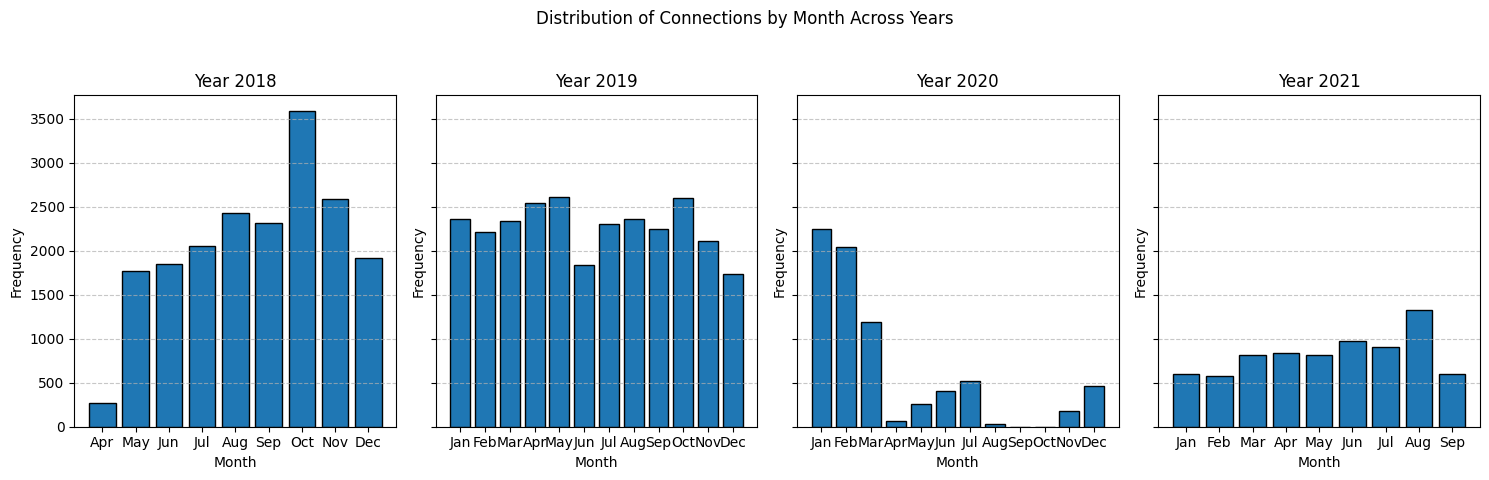

In [11]:
# Just a reminder
plot_hist_per_year(df=full_charging_df, title="Distribution of Connections by Month Across Years")

In [12]:
saisonfiguren_list = []
for year in sorted(full_charging_df["connectionYear"].unique()):
    saisonfiguren_list.append(calculate_seasonal_factors(full_charging_df[full_charging_df["season_year"] == year] , year))

saisonfiguren = pd.concat(saisonfiguren_list)
saisonfiguren = saisonfiguren.sort_values(['year', 'season']).reset_index(drop=True)
saisonfiguren

,year,season,record_count,seasonal_factor
0,2018,Spring,3277,0.530173
1,2018,Summer,6742,1.090762
2,2018,Autumn,8524,1.379065
3,2019,Winter,6299,0.928406
4,2019,Spring,7414,1.092745
5,2019,Summer,6717,0.990014
6,2019,Autumn,6709,0.988835
7,2020,Winter,5786,3.007277
8,2020,Spring,669,0.347713
9,2020,Summer,686,0.356549


In [13]:
saisonfiguren.groupby('season').mean()

/var/folders/ft/321k4kxs5r9cs1cshjn4m3rh0000gn/T/ipykernel_19292/894961869.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  saisonfiguren.groupby('season').mean()


,year,record_count,seasonal_factor
season,,,
Winter,2020.0,4620.666667,1.547477
Spring,2019.5,3469.500000,0.743022
Summer,2019.5,4348.250000,0.932280
Autumn,2019.0,5262.666667,0.885454


##### Explanation

This data seems to tell a specific story. First of all, in Spring 2018, we started our program (most likely; at least we began measuring). At that time, the service was quite new and needed to gain momentum. Subsequently, the summer and following autumn saw quite a few records, but this most likely was due to the growth trend and not just the seasonal pattern. In 2019, the service became established, and the seasonal pattern became visible. Although residuals are still present, they are not as significant as in 2018 or 2020. In 2020, the coronavirus pandemic hit, and the service was used less than in previous years. Additionally, our lack of data from August to November of this year makes the seasonal patterns quite unreliable. In 2021, the service usage increased again, and in the winter, it appears that the service recovered from the downturn earlier.

### Weeks
It also makes sense to calculate these factors for the weekdays. This can be done by calculating the factors for each weekday and year. This will give us a better understanding of the weekly patterns in the data. While also taking the yearly distribution into account. As it is imaginable that Covid-19 had also an impact on the weekly patterns as well.

In [14]:
full_charging_df["connectionWeekdayName"].value_counts()

connectionWeekdayName
Tuesday      11919
Wednesday    11723
Thursday     11548
Monday       11028
Friday        9506
Saturday      2714
Sunday        2483
Name: count, dtype: int64

In [15]:
weekday_factor_list = []
for year in years:
    weekday_factors = calculate_weekday_season_factors(full_charging_df[full_charging_df["connectionYear"] == year], "connectionWeekdayName", year)
    weekday_factor_list.append(weekday_factors)
weekday_factors = pd.concat(weekday_factor_list)
weekday_factors.sort_values(['year', 'weekday']).reset_index(drop=True)

,weekday,record_count,seasonal_factor,year
0,Monday,3099,1.155358,2018
1,Tuesday,3311,1.234395,2018
2,Wednesday,3263,1.216500,2018
3,Thursday,3255,1.213517,2018
4,Friday,3030,1.129634,2018
5,Saturday,1419,0.529026,2018
6,Sunday,1399,0.521570,2018
7,Monday,5128,1.316415,2019
8,Tuesday,5520,1.417046,2019
9,Wednesday,5507,1.413708,2019


In [16]:
# For all years
weekday_factors.drop(['year'], axis=1).groupby('weekday').mean()

/var/folders/ft/321k4kxs5r9cs1cshjn4m3rh0000gn/T/ipykernel_19292/103845545.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weekday_factors.drop(['year'], axis=1).groupby('weekday').mean()


,record_count,seasonal_factor
weekday,,
Monday,2757.00,1.276931
Tuesday,2979.75,1.389335
Wednesday,2930.75,1.352281
Thursday,2887.00,1.351614
Friday,2376.50,1.064860
Saturday,678.50,0.294558
Sunday,620.75,0.270420


#### Explanation
The data reveals distinct patterns in record counts and seasonal factors across the weekdays. The highest activity occurs on Tuesday (2,979.75 records, seasonal factor 1.39) and Wednesday (2,930.75 records, seasonal factor 1.35), closely followed by Monday and Thursday, which also show above-average activity levels. These weekdays consistently have seasonal factors greater than 1, indicating higher-than-average activity relative to the weekly baseline.

In contrast, Friday sees a moderate drop in activity (2,376.50 records, seasonal factor 1.06), while the lowest activity levels occur during the weekend. Saturday and Sunday show minimal records, with seasonal factors of 0.29 and 0.27, respectively, indicating significantly reduced activity on these days.

This data highlights a clear trend of weekday dominance in activity, with a sharp decline over the weekend.

### Daily Patterns  

#### Average number of new connections per hour

##### What is shown?

This chart shows the average number of **new connections (charges)** per hour throughout the day.

##### Results

- Most new connections occur between **6:00 and 8:00**, indicating a high arrival rate in the early morning hours.
- A small increase can be observed at **12:00**, which may be related to the lunch break.

#### Average number of connections per hour

##### What is shown?

This chart shows the average number of **connections** per hour, regardless of whether a vehicle is actually charging or just connected.

##### Results

- The total number of connections is highest during the day between **07:00 and 18:00**, which corresponds to a typical working day

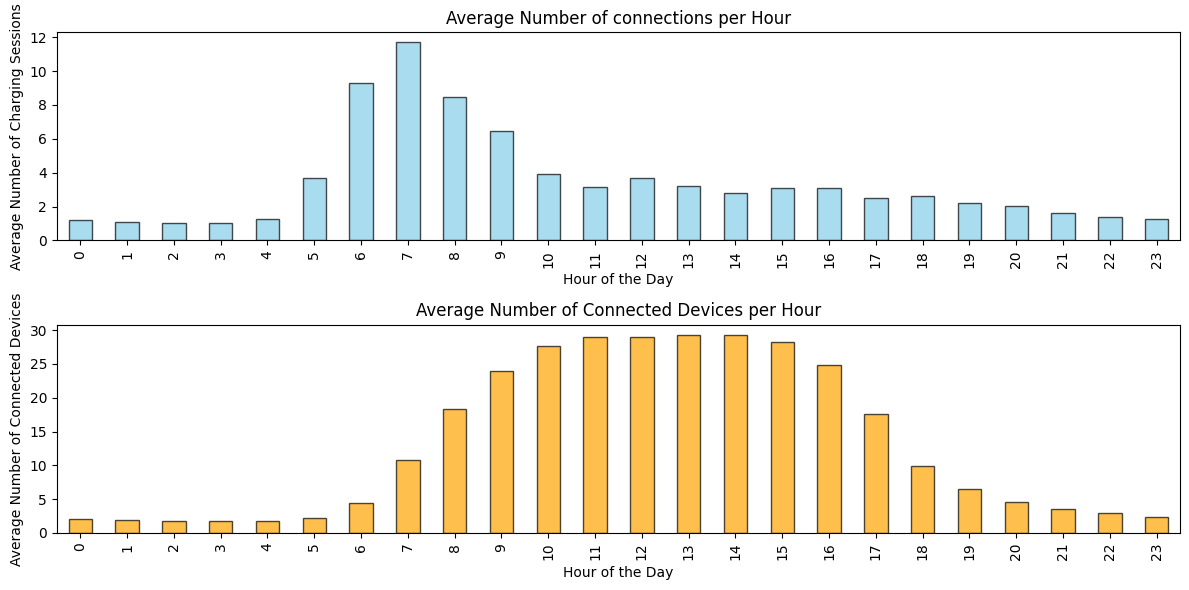

In [17]:
# Convert to Datetime format
full_charging_df['connectionTime'] = pd.to_datetime(full_charging_df['connectionTime'])
full_charging_df['disconnectTime'] = pd.to_datetime(full_charging_df['disconnectTime'])

# Extract date and hour
full_charging_df['date'] = full_charging_df['connectionTime'].dt.date
full_charging_df['connectionHour'] = full_charging_df['connectionTime'].dt.hour

# Count the number of charging sessions per hour
hourly_starts = full_charging_df.groupby(['date', 'connectionHour']).size().reset_index(name='count')

# Compute the average number of started charging sessions per hour
hourly_starts_avg = hourly_starts.groupby('connectionHour')['count'].mean()

# Generate a list of all hourly timestamps in the dataset
all_hours = pd.date_range(
    start=full_charging_df['connectionTime'].min(),
    end=full_charging_df['disconnectTime'].max(),
    freq='h'
)

connected_devices = []

# Count the number of connected devices per hour (per day)
for hour in all_hours:
    count = ((full_charging_df['connectionTime'] <= hour) & (full_charging_df['disconnectTime'] >= hour)).sum()
    connected_devices.append({'date': hour.date(), 'hour': hour.hour, 'connected_count': count})

# Create a DataFrame for connected devices
connected_devices_df = pd.DataFrame(connected_devices)

# Compute the average number of connected devices per hour
hourly_connected_avg = connected_devices_df.groupby('hour')['connected_count'].mean()

# Visualization
plt.figure(figsize=(12, 6))

# Chart 1
plt.subplot(2, 1, 1)
hourly_starts_avg.plot(kind='bar', color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Average Number of connections per Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Number of Charging Sessions')

# Chart 2
plt.subplot(2, 1, 2)
hourly_connected_avg.plot(kind='bar', color='orange', edgecolor='black', alpha=0.7)
plt.title('Average Number of Connected Devices per Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Number of Connected Devices')

plt.tight_layout()
plt.show()

Displaying the results in a table

In [18]:
# Ensure all 24 hours are included, filling missing values with 0
hourly_starts_avg_df = hourly_starts_avg.reindex(range(24), fill_value=0)
hourly_connected_avg_df = hourly_connected_avg.reindex(range(24), fill_value=0)

# Create a table with results
hourly_analysis_df = pd.DataFrame({
    'Hour': range(24),
    'Started Charging Sessions': hourly_starts_avg_df,
    'Connected Devices': hourly_connected_avg_df
})

# Format hour representation
hourly_analysis_df['Hour'] = hourly_analysis_df['Hour'].astype(str).str.zfill(2) + ':00'

hourly_analysis_df = hourly_analysis_df.set_index('Hour')

# Output table
print(hourly_analysis_df)

       Started Charging Sessions  Connected Devices
Hour                                               
00:00                   1.184874           2.115509
01:00                   1.101449           1.904915
02:00                   1.015625           1.782996
03:00                   1.043478           1.757674
04:00                   1.282675           1.794996
05:00                   3.664662           2.180791
06:00                   9.285891           4.438257
07:00                  11.698889          10.734463
08:00                   8.451288          18.302100
09:00                   6.467177          23.917609
10:00                   3.938529          27.661551
11:00                   3.128814          29.067044
12:00                   3.697928          28.955574
13:00                   3.223103          29.327141
14:00                   2.796231          29.305331
15:00                   3.113208          28.292407
16:00                   3.071038          24.908724
17:00       

#### End Time of Charging Sessions (Vehicle Disconnection Time)

##### What is shown?

This diagram displays the time at which most vehicles **disconnect** from the charging station, indicating when the station is freed up.

##### Results

- Vehicles start **disconnecting from 3:00 PM onwards**, suggesting that some users leave earlier or have shorter charging sessions.
- The **peak disconnection time is around 5:00 PM**, indicating that most users finish their workday or university schedule at this time.
- After **6:00 PM, the number of disconnections drops significantly**, meaning that most vehicles have already left

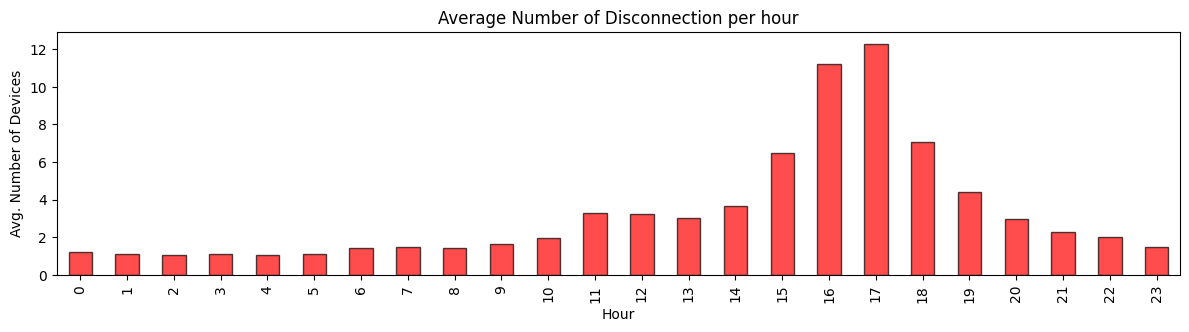

In [19]:
# Number of devices
hourly_disconnects = full_charging_df.groupby(['date', 'disconnectHour']).size().reset_index(name='count')

hourly_done = full_charging_df.groupby(['date', 'doneChargingHour']).size().reset_index(name='count')

# Average per hour across all days
hourly_disconnects_avg = hourly_disconnects.groupby('disconnectHour')['count'].mean()
hourly_done_avg = hourly_done.groupby('doneChargingHour')['count'].mean()

# Ensure all 24 hours are included, fill missing values with 0
hourly_disconnects_avg = hourly_disconnects_avg.reindex(range(24), fill_value=0)
hourly_done_avg = hourly_done_avg.reindex(range(24), fill_value=0)

# Visualization
plt.figure(figsize=(12, 6))

# Chart 1
plt.subplot(2, 1, 1)
hourly_disconnects_avg.plot(kind='bar', color='red', edgecolor='black', alpha=0.7)
plt.title('Average Number of Disconnection per hour')
plt.xlabel('Hour')
plt.ylabel('Avg. Number of Devices')


plt.tight_layout()
plt.show()

#### Average Charging and Connection Duration per Connection Hour

##### What is shown?

Bar chart showing **average charging duration (blue)** and **total connection duration (brown)** per hour.

###### Results

- Morning hours (2 AM - 7 AM) have the longest charging durations, suggesting overnight charging.
- Total connection duration remains high throughout the day, indicating vehicles stay connected after charging ends.
- Shorter durations in the afternoon suggest quick charging sessions, while evening connections likely last overnight.

<Figure size 1200x600 with 0 Axes>

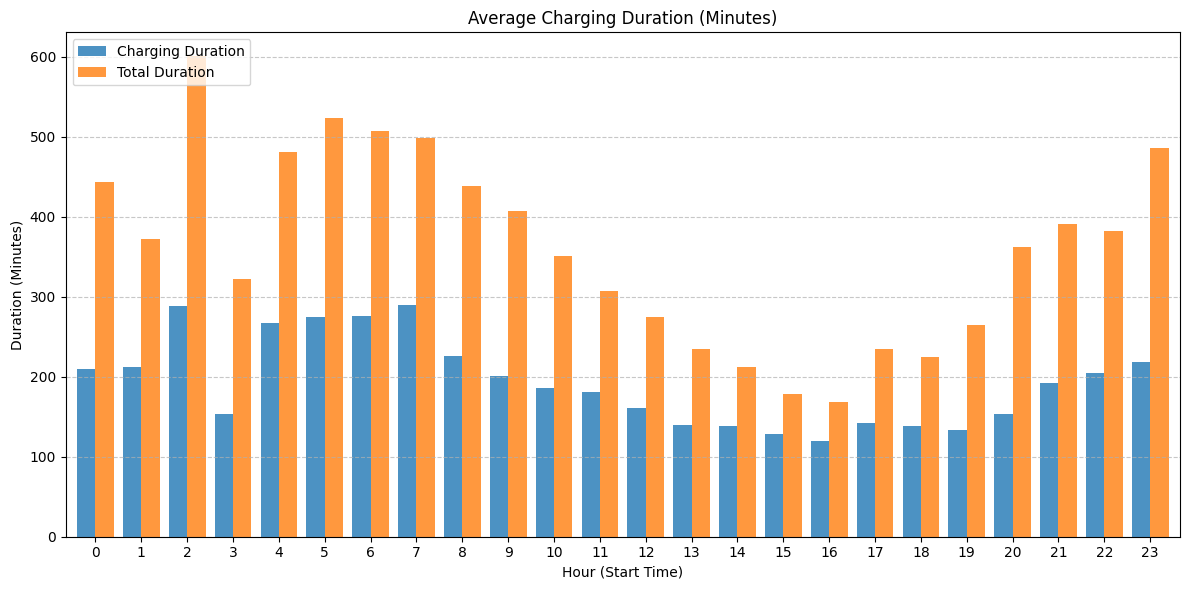

In [20]:
# Avg duration per connection hour
hourly_durations = full_charging_df.groupby('connectionHour').agg({
    'loading_duration': 'mean',
    'connected_duration': 'mean'
}).reindex(range(24), fill_value=0)

# Visualization
plt.figure(figsize=(12, 6))

hourly_durations.plot(kind='bar', figsize=(12, 6), width=0.8, alpha=0.8)
plt.title('Average Charging Duration (Minutes)')
plt.xlabel('Hour (Start Time)')
plt.ylabel('Duration (Minutes)')
plt.legend(['Charging Duration', 'Total Duration'], loc='upper left')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### Ratio of Charging Duration to Total Duration per Hour

##### What is shown?

- Line chart displaying the **average ratio of charging time to total connection time** per hour.
- Indicates how efficiently charging stations are used at different times of the day.

##### Results

- Lowest ratios occur in early morning hours (0-9 AM), meaning vehicles stay connected long after charging ends.
- Highest ratios between 3 PM - 5 PM, indicating that users disconnect shortly after charging is complete.

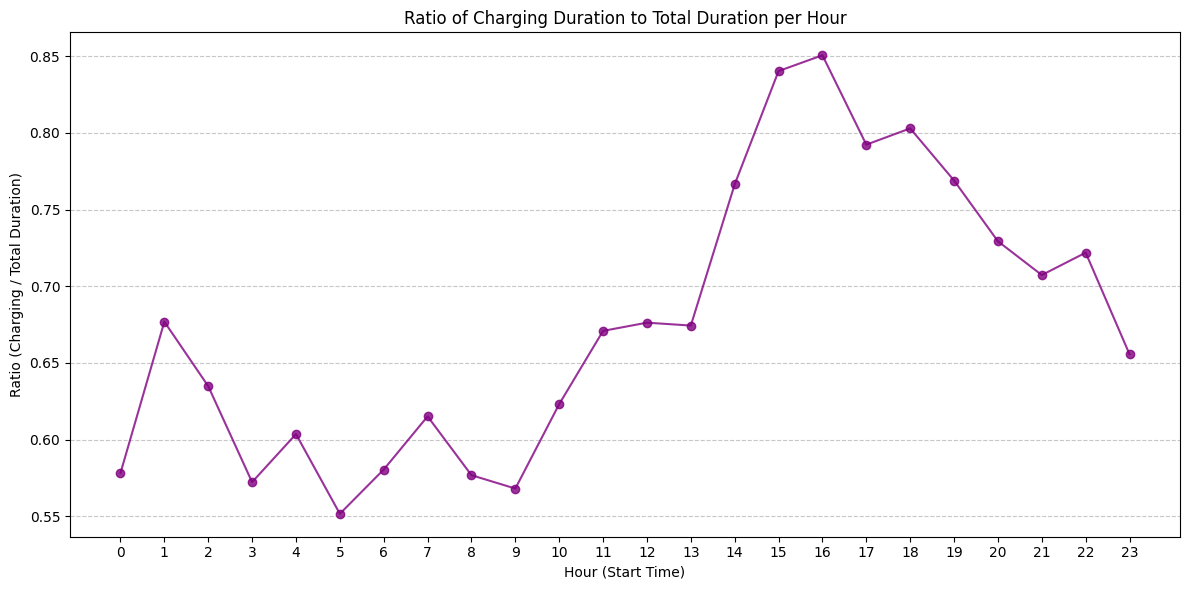

In [21]:
# Avg ratio of charging duration to total connected duration /h
hourly_ratios = full_charging_df.groupby('connectionHour')['ratio_loading_to_connected'].mean().reindex(range(24), fill_value=0)

# Visualization
plt.figure(figsize=(12, 6))
hourly_ratios.plot(kind='line', marker='o', color='purple', alpha=0.8)
plt.title('Ratio of Charging Duration to Total Duration per Hour')
plt.xlabel('Hour (Start Time)')
plt.ylabel('Ratio (Charging / Total Duration)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(range(24))
plt.tight_layout()
plt.show()

#### Average Charging vs. Connected-Only Devices per Hour

##### What is shown?

- Bar chart comparing the **average number of actively charging vehicles** (blue) vs. **vehicles that are only connected** (orange) per hour.
- Highlights the difference between energy consumption and station occupancy.

##### Results

- Peak charging activity occurs between 8 AM - 11 AM, aligning with morning arrivals.
- After 12 PM, the number of connected-but-not-charging vehicles surpasses actively charging ones, indicating prolonged station occupancy without energy consumption.

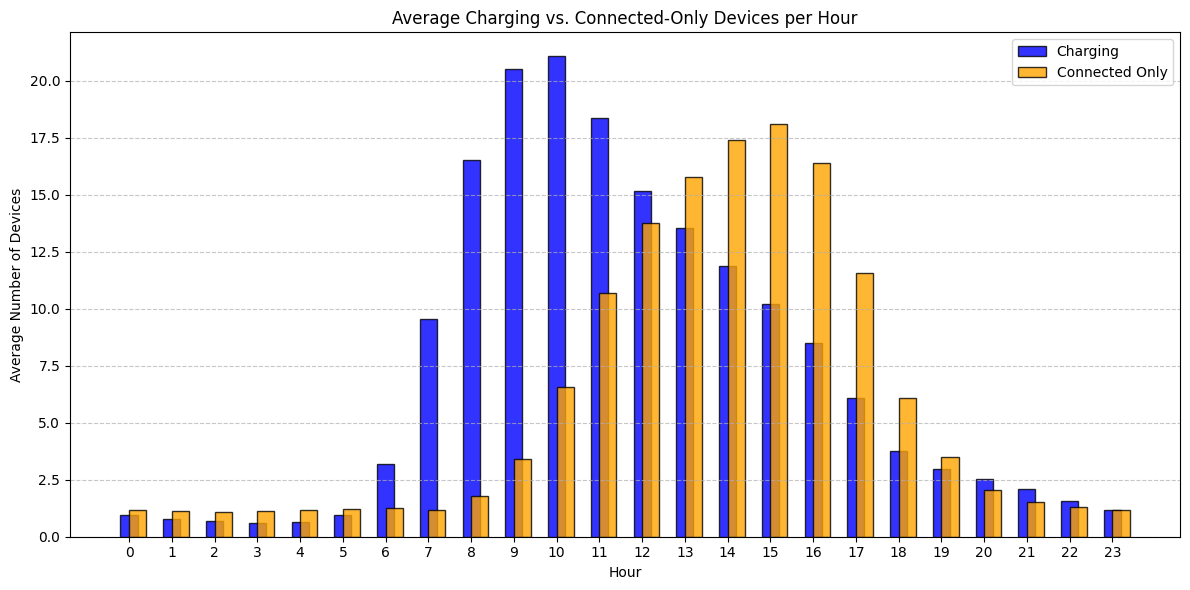

In [22]:
all_hours = pd.date_range(
    start=full_charging_df['connectionTime'].min(),
    end=full_charging_df['disconnectTime'].max(),
    freq='h'
)

active_loading = []
just_connected = []

# calculate indicators
for hour in all_hours:
    current_date = hour.date()
    current_hour = hour.hour

    # Actively charging devices
    loading_count = ((full_charging_df['connectionTime'] <= hour) &
                     (full_charging_df['doneChargingTime'] >= hour)).sum()

    # Connected but not charging devices
    connected_count = ((full_charging_df['connectionTime'] <= hour) &
                       (full_charging_df['disconnectTime'] >= hour)).sum()

    not_loading_count = connected_count - loading_count

    # results
    active_loading.append({'date': current_date, 'hour': current_hour, 'count': loading_count})
    just_connected.append({'date': current_date, 'hour': current_hour, 'count': not_loading_count})

# df
active_loading_df = pd.DataFrame(active_loading)
just_connected_df = pd.DataFrame(just_connected)

active_loading_avg = active_loading_df.groupby('hour')['count'].mean()
just_connected_avg = just_connected_df.groupby('hour')['count'].mean()

active_loading_avg = active_loading_avg.reindex(range(24), fill_value=0)
just_connected_avg = just_connected_avg.reindex(range(24), fill_value=0)

# Visualization
plt.figure(figsize=(12, 6))

x = range(24)
plt.bar(x, active_loading_avg, width=0.4, label='Charging', align='center', alpha=0.8, color='blue', edgecolor='black')
plt.bar(x, just_connected_avg, width=0.4, label='Connected Only', align='edge', alpha=0.8, color='orange', edgecolor='black')

plt.title('Average Charging vs. Connected-Only Devices per Hour')
plt.xlabel('Hour')
plt.ylabel('Average Number of Devices')
plt.xticks(range(24))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()